In [21]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [22]:
import json
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any
from scipy import stats
from scipy.stats import chi2_contingency

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

# Set paths (notebook is in analysis/ subdirectory, data files are in parent directory)
BASE_DIR = Path("..")  # Parent directory: results/medmcqa_2/
RESULTS_DIR = BASE_DIR
SAMPLES_DIR = BASE_DIR
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)


# MedMCQA Schema Analysis

This notebook analyzes the performance of different schema levels on the MedMCQA benchmark.

## Overview
- **Baseline (generate_until)**: Free-form generation without schema constraints
- **Level 1**: StrictMultipleChoice (answer only)
- **Level 2**: MCQAnswerWithConfidenceNew (answer + probabilities + confidence)
- **Level 3**: MCQAnswerWithJustification (answer + justification)
- **Level 4**: MultipleChoiceWithReasoning (answer + reasoning + confidence)
- **Level 5**: MCQWithFullElimination (answer + eliminated options + key evidence)
- **Level 6**: ComprehensiveMultipleChoice (answer + reasoning + confidence + key concepts)


## 1. Data Loading & Parsing


In [23]:
def load_results(result_file: str) -> Dict[str, Any]:
    """Load result JSON file and extract metrics."""
    with open(result_file, 'r') as f:
        data = json.load(f)
    return data

def load_samples(samples_file: str) -> List[Dict[str, Any]]:
    """Load sample JSONL file."""
    samples = []
    with open(samples_file, 'r') as f:
        for line in f:
            if line.strip():
                samples.append(json.loads(line))
    return samples

def extract_json_from_text(text: str) -> Optional[Dict]:
    """Extract JSON object from text, handling incomplete JSON."""
    if not text or not isinstance(text, str):
        return None
    
    text_cleaned = text.strip()
    
    # Try direct parse first
    try:
        return json.loads(text_cleaned)
    except (json.JSONDecodeError, TypeError):
        pass
    
    # Try to find complete JSON object using balanced braces
    start_idx = text_cleaned.find('{')
    if start_idx == -1:
        return None
    
    brace_count = 0
    for i in range(start_idx, len(text_cleaned)):
        if text_cleaned[i] == '{':
            brace_count += 1
        elif text_cleaned[i] == '}':
            brace_count -= 1
            if brace_count == 0:
                json_str = text_cleaned[start_idx:i+1]
                try:
                    return json.loads(json_str)
                except (json.JSONDecodeError, TypeError):
                    return None
    return None

# Load all result files
result_files = {
    'baseline_gen': 'False_medmcqa_generation_baseline_2025-12-11T08-21-06.604776.json',
    'L1': 'medmcqa_level1_2025-12-08T18-49-34.939793.json',
    'L2': 'medmcqa_level2_2025-12-08T22-15-47.472224.json',
    'L3': 'medmcqa_level3_2025-12-10T02-51-09.353135.json',
    'L4': 'medmcqa_level4_2025-12-10T17-18-56.377289.json',
    'L5': 'medmcqa_level5_2025-12-11T08-06-31.565470.json',
    'L6': 'medmcqa_level6_2025-12-11T21-30-51.473619.json',
}

sample_files = {
    'baseline_gen': 'samples_medmcqa_generation_2025-12-11T08-21-06.604776.jsonl',
    'L1': 'samples_medmcqa_generation_2025-12-08T18-49-34.939793.jsonl',
    'L2': 'samples_medmcqa_generation_2025-12-08T22-15-47.472224.jsonl',
    'L3': 'samples_medmcqa_generation_2025-12-10T02-51-09.353135.jsonl',
    'L4': 'samples_medmcqa_generation_2025-12-10T17-18-56.377289.jsonl',
    'L5': 'samples_medmcqa_generation_2025-12-11T08-06-31.565470.jsonl',
    'L6': 'samples_medmcqa_generation_2025-12-11T21-30-51.473619.jsonl',
}

# Load results
results = {}
for level, filename in result_files.items():
    filepath = RESULTS_DIR / filename
    if filepath.exists():
        results[level] = load_results(str(filepath))
        print(f"✓ Loaded {level}: {filename}")
    else:
        print(f"✗ Warning: {filename} not found")

# Load samples
samples = {}
for level, filename in sample_files.items():
    filepath = SAMPLES_DIR / filename
    if filepath.exists():
        samples[level] = load_samples(str(filepath))
        print(f"✓ Loaded {level} samples: {len(samples[level])} samples")
    else:
        print(f"✗ Warning: {filename} not found")

print(f"\nTotal levels loaded: {len(samples)}")


✓ Loaded baseline_gen: False_medmcqa_generation_baseline_2025-12-11T08-21-06.604776.json
✓ Loaded L1: medmcqa_level1_2025-12-08T18-49-34.939793.json
✓ Loaded L2: medmcqa_level2_2025-12-08T22-15-47.472224.json
✓ Loaded L3: medmcqa_level3_2025-12-10T02-51-09.353135.json
✓ Loaded L4: medmcqa_level4_2025-12-10T17-18-56.377289.json
✓ Loaded L5: medmcqa_level5_2025-12-11T08-06-31.565470.json
✓ Loaded L6: medmcqa_level6_2025-12-11T21-30-51.473619.json
✓ Loaded baseline_gen samples: 4183 samples
✓ Loaded L1 samples: 4183 samples
✓ Loaded L2 samples: 4183 samples
✓ Loaded L3 samples: 4183 samples
✓ Loaded L4 samples: 4183 samples
✓ Loaded L5 samples: 4183 samples
✓ Loaded L6 samples: 4183 samples

Total levels loaded: 7


In [24]:
def parse_sample(sample: Dict, level: str) -> Dict[str, Any]:
    """Parse a sample based on schema level with comprehensive extraction."""
    raw_resp = sample.get('resps', [[None]])[0][0] if sample.get('resps') else None
    filtered_resp = sample.get('filtered_resps', ['[invalid]'])[0]
    target = sample.get('target', '')
    exact_match = sample.get('exact_match', 0)
    doc_id = sample.get('doc_id', -1)
    
    parsed_data = {
        'doc_id': doc_id,
        'raw_response': raw_resp if raw_resp else '',
        'filtered_response': filtered_resp if filtered_resp else '[invalid]',
        'target': target,
        'exact_match': exact_match,
        'json_valid': False,
        'answer': None,
        'confidence': None,
        'probabilities': None,
        'justification': None,
        'has_answer': False,
        'has_confidence': False,
        'has_probabilities': False,
        'has_justification': False,
        'confidence_valid': False,
        'schema_compliant': False,
    }
    
    # Baseline generate_until: parse like schema levels but without schema constraints
    if level == 'baseline_gen':
        # Similar to schema levels but uses free-form prompt
        if raw_resp and isinstance(raw_resp, str):
            # Try to extract answer from filtered response (regex-based)
            answer = filtered_resp.strip().upper() if filtered_resp else '[invalid]'
            if answer in ['A', 'B', 'C', 'D']:
                parsed_data['answer'] = answer
                parsed_data['has_answer'] = True
            else:
                parsed_data['answer'] = '[invalid]'
        return parsed_data
    
    # Schema levels: parse JSON
    if raw_resp and isinstance(raw_resp, str):
        parsed_json = extract_json_from_text(raw_resp)
        if parsed_json and isinstance(parsed_json, dict):
            parsed_data['json_valid'] = True
            parsed_data['answer'] = parsed_json.get('answer', '').strip().upper()
            parsed_data['has_answer'] = parsed_data['answer'] in ['A', 'B', 'C', 'D']
            
            # Extract confidence
            if 'confidence' in parsed_json:
                try:
                    conf = float(parsed_json['confidence'])
                    parsed_data['confidence'] = conf
                    parsed_data['has_confidence'] = True
                    parsed_data['confidence_valid'] = (0.0 <= conf <= 1.0)
                except (ValueError, TypeError):
                    pass
            
            # Extract probabilities (Level 2)
            if 'probabilities' in parsed_json:
                probs = parsed_json['probabilities']
                if isinstance(probs, dict):
                    parsed_data['probabilities'] = probs
                    parsed_data['has_probabilities'] = True
            
            # Extract justification (Level 3)
            parsed_data['justification'] = parsed_json.get('justification', '')
            parsed_data['has_justification'] = bool(parsed_data['justification'])
            
            # Check schema compliance based on level
            if level == 'L1':
                parsed_data['schema_compliant'] = parsed_data['json_valid'] and parsed_data['has_answer']
            elif level == 'L2':
                parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'] 
                                                   and parsed_data['has_probabilities'] and parsed_data['has_confidence']
                                                   and parsed_data['confidence_valid'])
            elif level in ['L3', 'L4', 'L5', 'L6']:
                parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'])
        else:
            # Fallback to filtered response
            answer = filtered_resp.strip().upper() if filtered_resp else '[invalid]'
            if answer in ['A', 'B', 'C', 'D']:
                parsed_data['answer'] = answer
                parsed_data['has_answer'] = True
            else:
                parsed_data['answer'] = '[invalid]'
    
    return parsed_data

# Parse all samples
parsed_samples = {}
for level in samples.keys():
    parsed_samples[level] = [parse_sample(s, level) for s in samples[level]]
    print(f"✓ Parsed {len(parsed_samples[level])} samples for {level}")


✓ Parsed 4183 samples for baseline_gen
✓ Parsed 4183 samples for L1
✓ Parsed 4183 samples for L2
✓ Parsed 4183 samples for L3
✓ Parsed 4183 samples for L4
✓ Parsed 4183 samples for L5
✓ Parsed 4183 samples for L6


Performance Summary:
       Level     score    stderr      metric
baseline_gen  0.508965  0.007731 exact_match
          L1  0.545063    0.0077 exact_match
          L2  0.539565  0.007708 exact_match
          L3  0.545063    0.0077 exact_match
          L4  0.545302    0.0077 exact_match
          L5  0.535262  0.007713 exact_match
          L6  0.545063    0.0077 exact_match



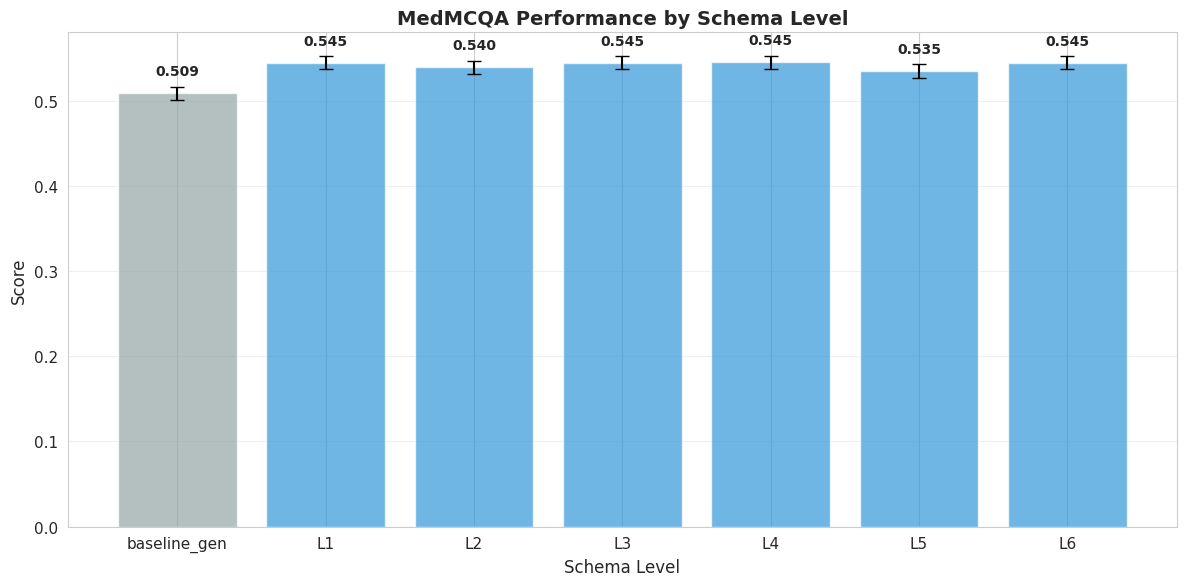


Performance difference from baseline_gen:
  L1: +0.036 (+7.1%)
  L2: +0.031 (+6.0%)
  L3: +0.036 (+7.1%)
  L4: +0.036 (+7.1%)
  L5: +0.026 (+5.2%)
  L6: +0.036 (+7.1%)


In [25]:
# Extract performance metrics
performance_data = {}

for level in ['baseline_gen', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']:
    if level in results:
        result = results[level]
        # All levels use generate_until
        if 'medmcqa_generation' in result['results']:
            exact_match = result['results']['medmcqa_generation'].get('exact_match,strict-match', 0)
            exact_match_stderr = result['results']['medmcqa_generation'].get('exact_match_stderr,strict-match', 0)
            performance_data[level] = {
                'score': exact_match,
                'stderr': exact_match_stderr,
                'metric': 'exact_match'
            }

# Create performance DataFrame
perf_df = pd.DataFrame(performance_data).T
perf_df.index.name = 'Level'
perf_df = perf_df.reset_index()

print("Performance Summary:")
print(perf_df.to_string(index=False))
print()

# Visualize performance comparison
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(perf_df))
colors = ['#95a5a6' if l == 'baseline_gen' else '#3498db' for l in perf_df['Level']]
bars = ax.bar(x_pos, perf_df['score'], yerr=perf_df['stderr'], 
              capsize=5, alpha=0.7, color=colors)

ax.set_xlabel('Schema Level', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('MedMCQA Performance by Schema Level', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(perf_df['Level'])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, score, stderr) in enumerate(zip(bars, perf_df['score'], perf_df['stderr'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + stderr + 0.01,
            f'{score:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPerformance difference from baseline_gen:")
if 'baseline_gen' in perf_df['Level'].values:
    baseline_score = perf_df[perf_df['Level'] == 'baseline_gen']['score'].values[0]
    for _, row in perf_df.iterrows():
        if row['Level'] != 'baseline_gen':
            diff = row['score'] - baseline_score
            pct_diff = (diff / baseline_score) * 100
            print(f"  {row['Level']}: {diff:+.3f} ({pct_diff:+.1f}%)")


## 3. Schema Compliance Analysis


Schema Compliance Rates:
    json_valid_pct  has_answer_pct  schema_compliant_pct
L1       95.242649       95.242649             95.242649
L2       94.453741       94.525460             94.429835
L3       94.166866       95.242649             94.166866
L4       71.647143       95.290461             71.647143
L5       93.282333       93.425771             93.282333
L6       81.042314       95.194836             81.042314



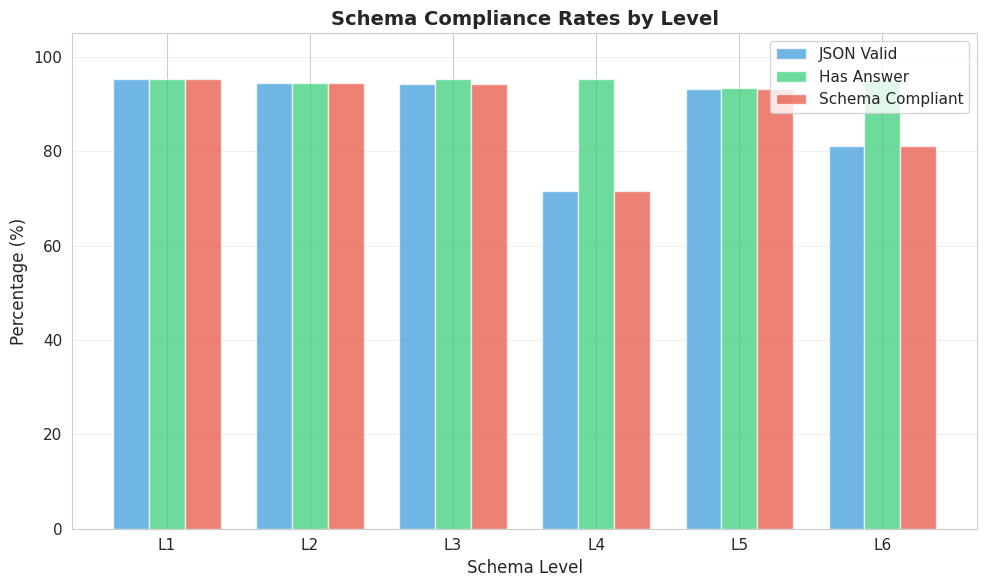

In [26]:
# Analyze schema compliance rates
compliance_data = {}

for level in ['L1', 'L2', 'L3', 'L4', 'L5', 'L6']:
    if level in parsed_samples:
        level_samples = parsed_samples[level]
        total = len(level_samples)
        json_valid = sum(1 for s in level_samples if s['json_valid'])
        schema_compliant = sum(1 for s in level_samples if s['schema_compliant'])
        has_answer = sum(1 for s in level_samples if s['has_answer'])
        
        compliance_data[level] = {
            'total': total,
            'json_valid': json_valid,
            'json_valid_pct': (json_valid / total) * 100,
            'has_answer': has_answer,
            'has_answer_pct': (has_answer / total) * 100,
            'schema_compliant': schema_compliant,
            'schema_compliant_pct': (schema_compliant / total) * 100,
        }

compliance_df = pd.DataFrame(compliance_data).T
print("Schema Compliance Rates:")
print(compliance_df[['json_valid_pct', 'has_answer_pct', 'schema_compliant_pct']].to_string())
print()

# Visualize compliance rates
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(compliance_df))
width = 0.25

metrics = ['json_valid_pct', 'has_answer_pct', 'schema_compliant_pct']
labels = ['JSON Valid', 'Has Answer', 'Schema Compliant']
colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, (metric, label, color) in enumerate(zip(metrics, labels, colors)):
    ax.bar(x + i*width, compliance_df[metric], width, label=label, color=color, alpha=0.7)

ax.set_xlabel('Schema Level', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Schema Compliance Rates by Level', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(compliance_df.index)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 105])

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'compliance_rates.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Answer Distribution Analysis


Answer Distribution (%):
                      A          B          C          D
baseline_gen  49.784715  19.348762  16.496233  14.370291
L1            32.756024  27.560241  26.305221  13.378514
L2            32.852807  27.465857  26.327769  13.353566
L3            32.756024  27.560241  26.305221  13.378514
L4            32.839940  27.521325  26.241846  13.396889
L5            32.676561  27.635619  26.177073  13.510747
L6            32.822702  27.473631  26.293320  13.410347



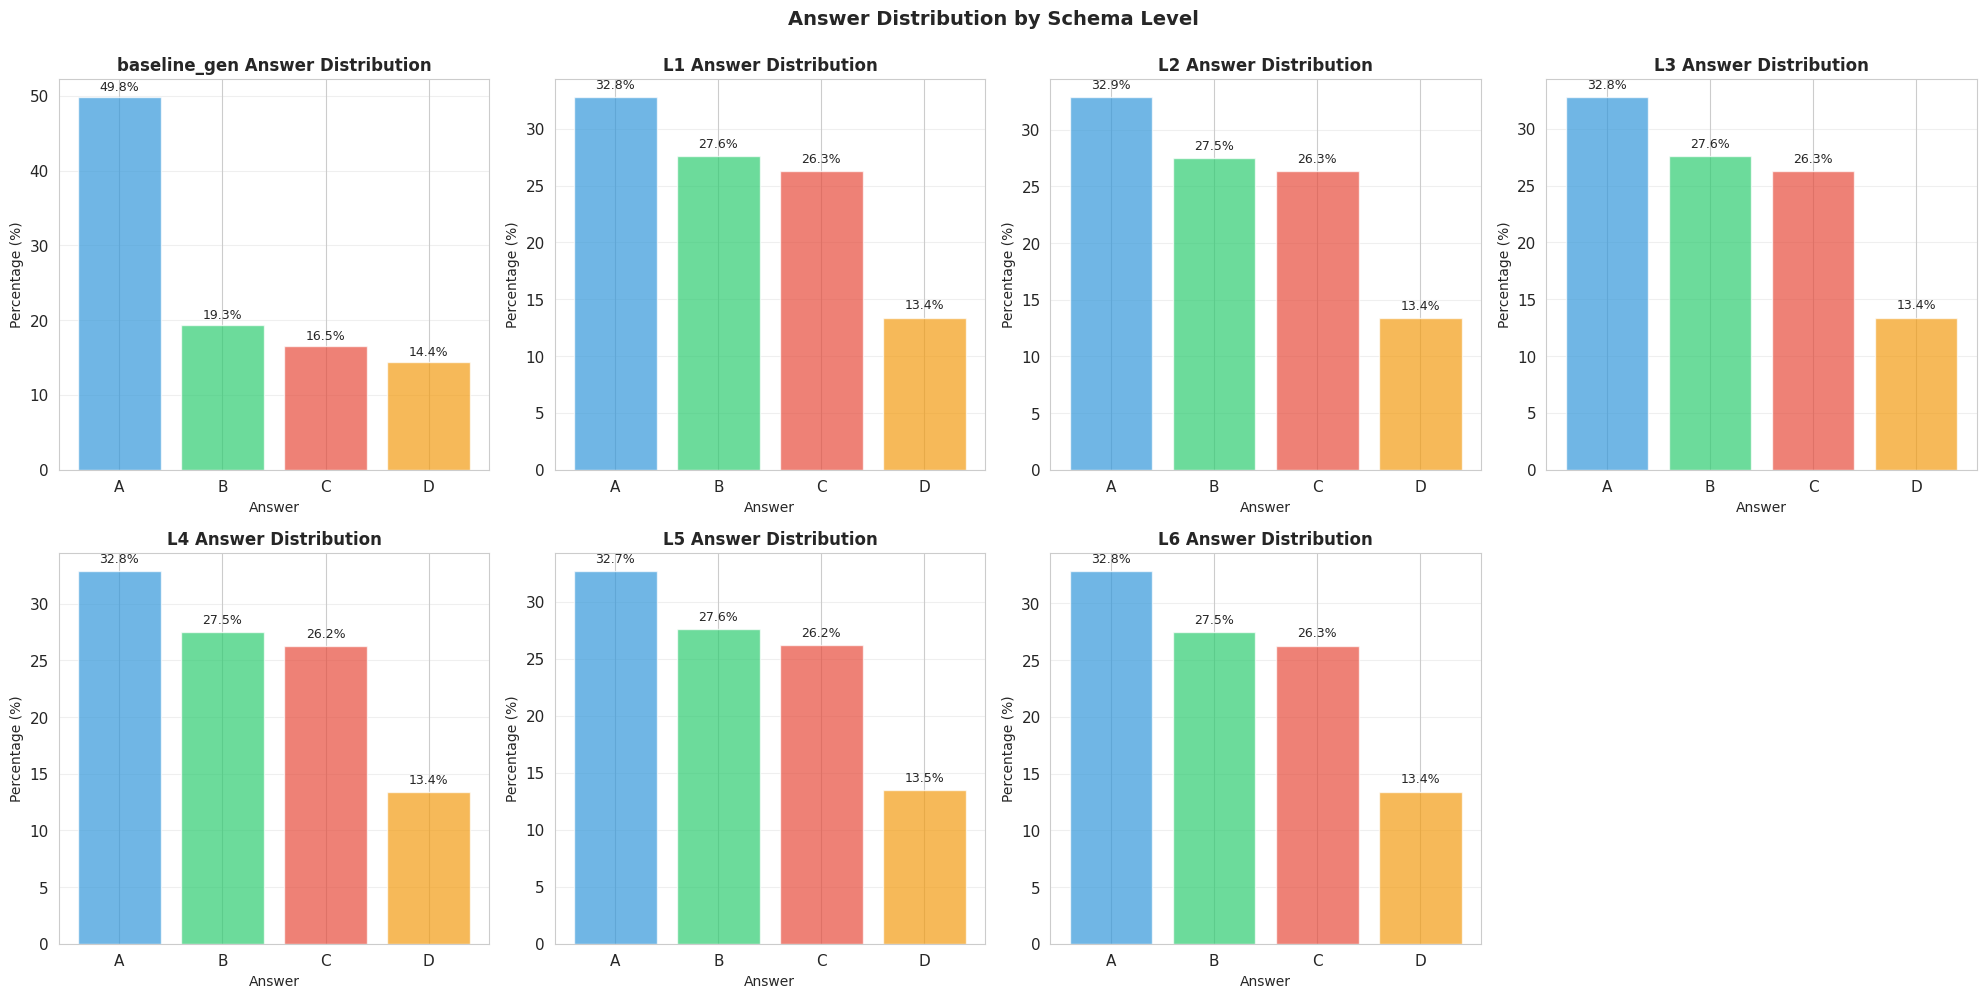

In [27]:
# Analyze answer distributions
answer_distributions = {}

for level in ['baseline_gen', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']:
    if level in parsed_samples:
        level_samples = parsed_samples[level]
        answers = [s['answer'] for s in level_samples if s['has_answer']]
        answer_counts = Counter(answers)
        total_valid = len(answers)
        
        answer_distributions[level] = {
            answer: (count / total_valid * 100) if total_valid > 0 else 0
            for answer, count in answer_counts.items()
        }

# Create distribution DataFrame
dist_df = pd.DataFrame(answer_distributions).T
dist_df = dist_df.fillna(0)
dist_df = dist_df[['A', 'B', 'C', 'D', '[invalid]']] if '[invalid]' in dist_df.columns else dist_df[['A', 'B', 'C', 'D']]

print("Answer Distribution (%):")
print(dist_df.to_string())
print()

# Visualize answer distributions
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
levels_to_plot = ['baseline_gen', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']
for idx, level in enumerate(levels_to_plot):
    row = idx // 4
    col = idx % 4
    ax = axes[row, col]
    if level in dist_df.index:
        data = dist_df.loc[level]
        colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#95a5a6']
        bars = ax.bar(data.index, data.values, color=colors[:len(data)], alpha=0.7)
        ax.set_title(f'{level} Answer Distribution', fontsize=12, fontweight='bold')
        ax.set_ylabel('Percentage (%)', fontsize=10)
        ax.set_xlabel('Answer', fontsize=10)
        ax.grid(axis='y', alpha=0.3)
        
        # Add value labels
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                       f'{height:.1f}%',
                       ha='center', va='bottom', fontsize=9)

# Hide unused subplots
for idx in range(len(levels_to_plot), 8):
    row = idx // 4
    col = idx % 4
    axes[row, col].axis('off')

plt.suptitle('Answer Distribution by Schema Level', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'answer_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Error Analysis


Error Breakdown (%):
              invalid_response  missing_answer
baseline_gen         11.164236       11.164236
L1                         NaN        0.000000
L2                         NaN        0.000000
L3                         NaN        0.000000
L4                         NaN        0.000000
L5                         NaN        0.000000
L6                         NaN        0.000000



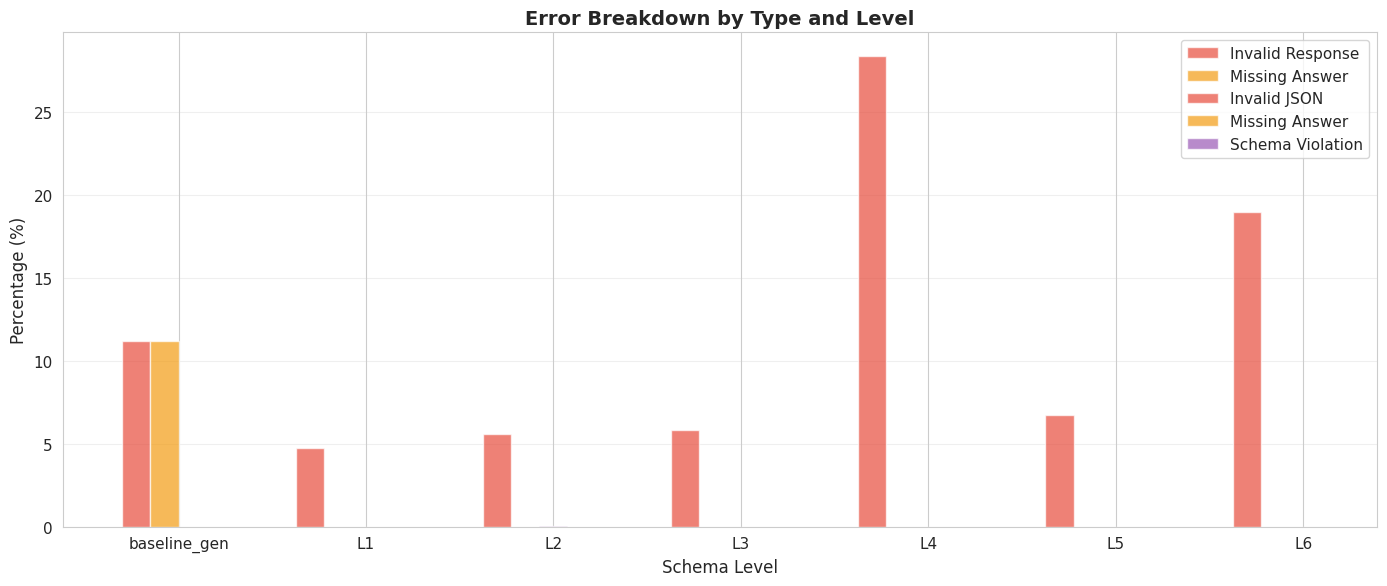

In [28]:
# Analyze errors by type
error_analysis = {}

for level in ['baseline_gen', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']:
    if level in parsed_samples:
        level_samples = parsed_samples[level]
        total = len(level_samples)
        
        if level == 'baseline_gen':
            errors = {
                'invalid_response': sum(1 for s in level_samples if s['filtered_response'] == '[invalid]' or not s['has_answer']),
                'missing_answer': sum(1 for s in level_samples if not s['has_answer']),
            }
        else:
            errors = {
                'invalid_json': sum(1 for s in level_samples if not s['json_valid']),
                'missing_answer': sum(1 for s in level_samples if s['json_valid'] and not s['has_answer']),
                'invalid_answer': sum(1 for s in level_samples if not s['has_answer']),
                'schema_violation': sum(1 for s in level_samples if s['json_valid'] and not s['schema_compliant']),
            }
        
        error_analysis[level] = {
            'total': total,
            **{k: (v / total * 100) for k, v in errors.items()}
        }

error_df = pd.DataFrame(error_analysis).T
print("Error Breakdown (%):")
if 'baseline_gen' in error_df.index:
    print(error_df[['invalid_response', 'missing_answer']].to_string())
else:
    print(error_df[['invalid_json', 'missing_answer', 'schema_violation']].to_string())
print()

# Visualize error breakdown
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(error_df))
width = 0.15

# Separate baseline_gen from schema levels
schema_levels = [l for l in error_df.index if l != 'baseline_gen']
baseline_levels = [l for l in error_df.index if l == 'baseline_gen']

if baseline_levels and 'invalid_response' in error_df.columns:
    error_types_baseline = ['invalid_response', 'missing_answer']
    labels_baseline = ['Invalid Response', 'Missing Answer']
    colors_baseline = ['#e74c3c', '#f39c12']
    for i, (err_type, label, color) in enumerate(zip(error_types_baseline, labels_baseline, colors_baseline)):
        if err_type in error_df.columns:
            baseline_idx = error_df.index.get_loc('baseline_gen')
            ax.bar(baseline_idx + i*width - width/2, error_df.loc['baseline_gen', err_type], 
                   width, label=label, color=color, alpha=0.7)

if schema_levels and 'invalid_json' in error_df.columns:
    error_types_schema = ['invalid_json', 'missing_answer', 'schema_violation']
    labels_schema = ['Invalid JSON', 'Missing Answer', 'Schema Violation']
    colors_schema = ['#e74c3c', '#f39c12', '#9b59b6']
    for i, (err_type, label, color) in enumerate(zip(error_types_schema, labels_schema, colors_schema)):
        if err_type in error_df.columns:
            for level in schema_levels:
                level_idx = error_df.index.get_loc(level)
                ax.bar(level_idx + i*width - width, error_df.loc[level, err_type], 
                       width, label=label if level == schema_levels[0] else '', color=color, alpha=0.7)

ax.set_xlabel('Schema Level', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Error Breakdown by Type and Level', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(error_df.index)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'error_breakdown_stacked.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Level-Specific Analysis

### Level 2: Confidence and Probabilities Analysis


Level 2 Confidence Statistics:
  Count: 3951
  Mean: 0.714
  Median: 1.000
  Std: 1.640
  Min: 0.000
  Max: 100.000



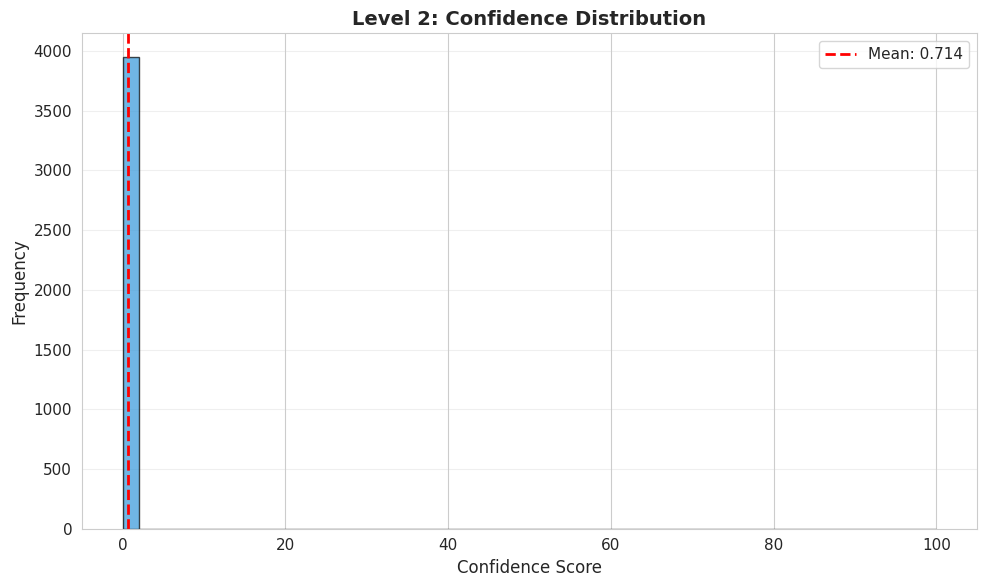

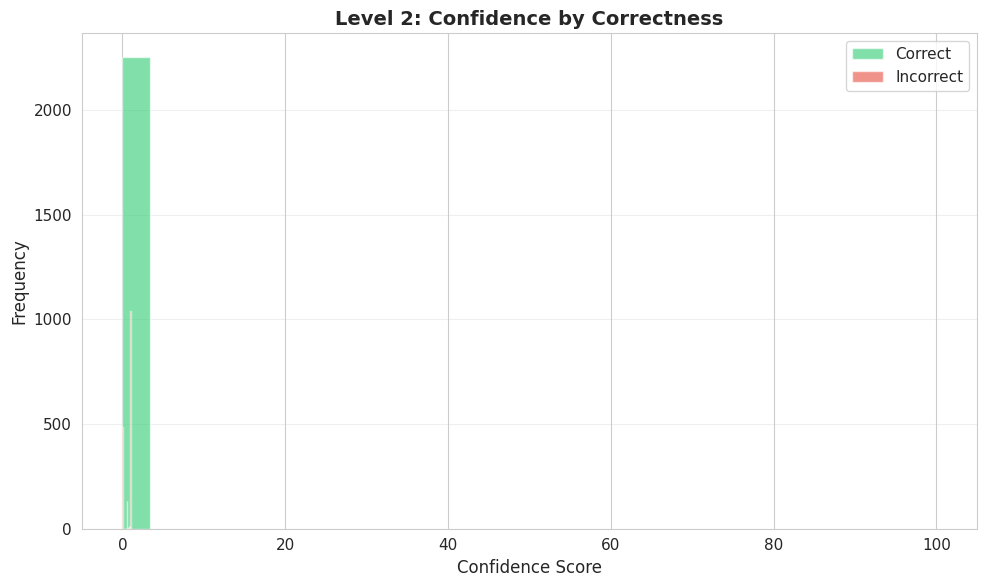

Confidence by Correctness:
  Correct answers - Mean: 0.745, Median: 1.000
  Incorrect answers - Mean: 0.672, Median: 1.000



In [29]:
# Analyze Level 2 (confidence and probabilities)
if 'L2' in parsed_samples:
    l2_samples = parsed_samples['L2']
    confidences = [s['confidence'] for s in l2_samples if s['has_confidence'] and s['confidence'] is not None]
    
    if confidences:
        print(f"Level 2 Confidence Statistics:")
        print(f"  Count: {len(confidences)}")
        print(f"  Mean: {np.mean(confidences):.3f}")
        print(f"  Median: {np.median(confidences):.3f}")
        print(f"  Std: {np.std(confidences):.3f}")
        print(f"  Min: {np.min(confidences):.3f}")
        print(f"  Max: {np.max(confidences):.3f}")
        print()
        
        # Plot confidence distribution
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.hist(confidences, bins=50, alpha=0.7, color='#3498db', edgecolor='black')
        ax.axvline(np.mean(confidences), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(confidences):.3f}')
        ax.set_xlabel('Confidence Score', fontsize=12)
        ax.set_ylabel('Frequency', fontsize=12)
        ax.set_title('Level 2: Confidence Distribution', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / 'confidence_analysis.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        # Analyze confidence by correctness
        correct_conf = [s['confidence'] for s in l2_samples 
                       if s['has_confidence'] and s['confidence'] is not None and s['exact_match'] == 1]
        incorrect_conf = [s['confidence'] for s in l2_samples 
                         if s['has_confidence'] and s['confidence'] is not None and s['exact_match'] == 0]
        
        if correct_conf and incorrect_conf:
            fig, ax = plt.subplots(figsize=(10, 6))
            ax.hist(correct_conf, bins=30, alpha=0.6, label='Correct', color='#2ecc71')
            ax.hist(incorrect_conf, bins=30, alpha=0.6, label='Incorrect', color='#e74c3c')
            ax.set_xlabel('Confidence Score', fontsize=12)
            ax.set_ylabel('Frequency', fontsize=12)
            ax.set_title('Level 2: Confidence by Correctness', fontsize=14, fontweight='bold')
            ax.legend()
            ax.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            plt.savefig(PLOTS_DIR / 'confidence_by_correctness.png', dpi=150, bbox_inches='tight')
            plt.show()
            
            print(f"Confidence by Correctness:")
            print(f"  Correct answers - Mean: {np.mean(correct_conf):.3f}, Median: {np.median(correct_conf):.3f}")
            print(f"  Incorrect answers - Mean: {np.mean(incorrect_conf):.3f}, Median: {np.median(incorrect_conf):.3f}")
            print()


### Level 3: Justification Analysis


Level 3 Justification Statistics:
  Count: 3939
  Mean length: 185.7 chars
  Median length: 200.0 chars
  Min length: 12 chars
  Max length: 200 chars



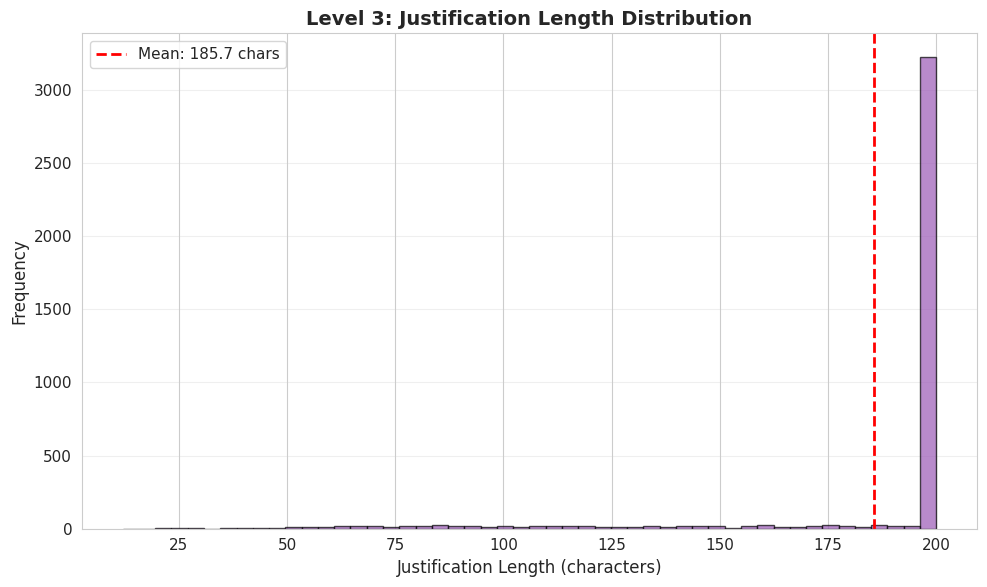

In [30]:
# Analyze Level 3 (justification)
if 'L3' in parsed_samples:
    l3_samples = parsed_samples['L3']
    justifications = [s['justification'] for s in l3_samples if s['has_justification']]
    
    if justifications:
        justification_lengths = [len(j) for j in justifications if j]
        
        print(f"Level 3 Justification Statistics:")
        print(f"  Count: {len(justifications)}")
        if justification_lengths:
            print(f"  Mean length: {np.mean(justification_lengths):.1f} chars")
            print(f"  Median length: {np.median(justification_lengths):.1f} chars")
            print(f"  Min length: {np.min(justification_lengths)} chars")
            print(f"  Max length: {np.max(justification_lengths)} chars")
        print()
        
        # Plot justification length distribution
        if justification_lengths:
            fig, ax = plt.subplots(figsize=(10, 6))
            ax.hist(justification_lengths, bins=50, alpha=0.7, color='#9b59b6', edgecolor='black')
            ax.axvline(np.mean(justification_lengths), color='red', linestyle='--', linewidth=2, 
                      label=f'Mean: {np.mean(justification_lengths):.1f} chars')
            ax.set_xlabel('Justification Length (characters)', fontsize=12)
            ax.set_ylabel('Frequency', fontsize=12)
            ax.set_title('Level 3: Justification Length Distribution', fontsize=14, fontweight='bold')
            ax.legend()
            ax.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            plt.savefig(PLOTS_DIR / 'reasoning_length_analysis.png', dpi=150, bbox_inches='tight')
            plt.show()


## 7. Cross-Schema Agreement Analysis


Cross-Schema Agreement:
  baseline_gen vs L1: 2731/3538 (77.2%)
  baseline_gen vs L2: 2710/3511 (77.2%)
  baseline_gen vs L3: 2731/3538 (77.2%)
  baseline_gen vs L4: 2734/3540 (77.2%)
  baseline_gen vs L5: 2680/3476 (77.1%)
  baseline_gen vs L6: 2730/3536 (77.2%)
  L1 vs L2: 3916/3949 (99.2%)
  L2 vs L3: 3916/3949 (99.2%)
  L3 vs L4: 3981/3984 (99.9%)
  L4 vs L5: 3898/3907 (99.8%)
  L5 vs L6: 3900/3906 (99.8%)



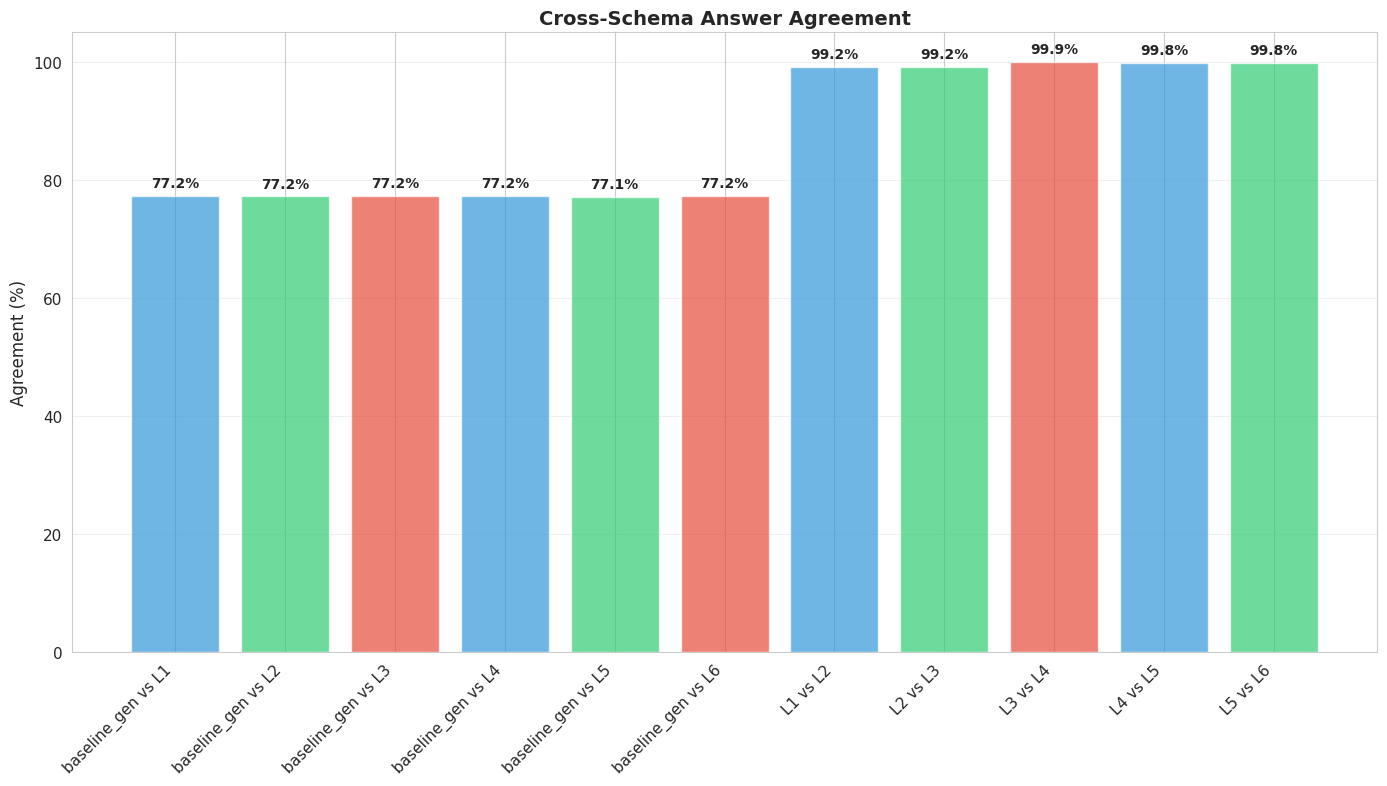

In [31]:
# Compare answers across schema levels
levels_to_compare = ['baseline_gen', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']
if all(level in parsed_samples for level in levels_to_compare):
    # Create a DataFrame with answers from all levels
    comparison_data = []
    max_samples = min([len(parsed_samples[level]) for level in levels_to_compare])
    
    for i in range(max_samples):
        row = {'doc_id': parsed_samples['L1'][i]['doc_id']}
        for level in levels_to_compare:
            answer = parsed_samples[level][i]['answer']
            row[f'{level}_answer'] = answer if answer in ['A', 'B', 'C', 'D'] else None
            row[f'{level}_correct'] = parsed_samples[level][i]['exact_match']
        comparison_data.append(row)
    
    comp_df = pd.DataFrame(comparison_data)
    
    # Calculate agreement
    print("Cross-Schema Agreement:")
    # Show baseline vs each level, and adjacent level pairs
    key_pairs = [('baseline_gen', 'L1'), ('baseline_gen', 'L2'), ('baseline_gen', 'L3'),
                 ('baseline_gen', 'L4'), ('baseline_gen', 'L5'), ('baseline_gen', 'L6'),
                 ('L1', 'L2'), ('L2', 'L3'), ('L3', 'L4'), ('L4', 'L5'), ('L5', 'L6')]
    
    for level1, level2 in key_pairs:
        col1 = f'{level1}_answer'
        col2 = f'{level2}_answer'
        both_valid = comp_df[[col1, col2]].notna().all(axis=1)
        if both_valid.sum() > 0:
            agreement = (comp_df.loc[both_valid, col1] == comp_df.loc[both_valid, col2]).sum()
            total = both_valid.sum()
            pct = (agreement / total) * 100
            print(f"  {level1} vs {level2}: {agreement}/{total} ({pct:.1f}%)")
    print()
    
    # Visualize agreement (show key comparisons)
    fig, ax = plt.subplots(figsize=(14, 8))
    agreements = []
    labels = []
    
    for level1, level2 in key_pairs:
        col1 = f'{level1}_answer'
        col2 = f'{level2}_answer'
        both_valid = comp_df[[col1, col2]].notna().all(axis=1)
        if both_valid.sum() > 0:
            agreement = (comp_df.loc[both_valid, col1] == comp_df.loc[both_valid, col2]).sum()
            total = both_valid.sum()
            pct = (agreement / total) * 100
            agreements.append(pct)
            labels.append(f'{level1} vs {level2}')
    
    bars = ax.bar(labels, agreements, color=['#3498db', '#2ecc71', '#e74c3c'], alpha=0.7)
    ax.set_ylabel('Agreement (%)', fontsize=12)
    ax.set_title('Cross-Schema Answer Agreement', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 105])
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar, val in zip(bars, agreements):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
               f'{val:.1f}%',
               ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'cross_schema_agreement.png', dpi=150, bbox_inches='tight')
    plt.show()


## 8. Summary and Conclusions


In [32]:
# Create summary statistics
print("=" * 80)
print("MEDMCQA SCHEMA ANALYSIS SUMMARY")
print("=" * 80)
print()

print("1. PERFORMANCE COMPARISON:")
print("-" * 40)
for _, row in perf_df.iterrows():
    print(f"  {row['Level']:10s}: {row['score']:.3f} ± {row['stderr']:.3f} ({row['metric']})")
print()

print("2. KEY FINDINGS:")
print("-" * 40)
if 'baseline_gen' in perf_df['Level'].values:
    baseline_score = perf_df[perf_df['Level'] == 'baseline_gen']['score'].values[0]
    for _, row in perf_df.iterrows():
        if row['Level'] != 'baseline_gen':
            diff = row['score'] - baseline_score
            pct_diff = (diff / baseline_score) * 100
            status = "⚠️ DEGRADATION" if diff < 0 else "✓ IMPROVEMENT"
            print(f"  {row['Level']}: {status} ({pct_diff:+.1f}%)")
print()

if 'L1' in compliance_df.index:
    print("3. SCHEMA COMPLIANCE:")
    print("-" * 40)
    for level in ['L1', 'L2', 'L3', 'L4', 'L5', 'L6']:
        if level in compliance_df.index:
            comp = compliance_df.loc[level]
            print(f"  {level}:")
            print(f"    JSON Valid: {comp['json_valid_pct']:.1f}%")
            print(f"    Has Answer: {comp['has_answer_pct']:.1f}%")
            print(f"    Schema Compliant: {comp['schema_compliant_pct']:.1f}%")
    print()

print("=" * 80)


MEDMCQA SCHEMA ANALYSIS SUMMARY

1. PERFORMANCE COMPARISON:
----------------------------------------
  baseline_gen: 0.509 ± 0.008 (exact_match)
  L1        : 0.545 ± 0.008 (exact_match)
  L2        : 0.540 ± 0.008 (exact_match)
  L3        : 0.545 ± 0.008 (exact_match)
  L4        : 0.545 ± 0.008 (exact_match)
  L5        : 0.535 ± 0.008 (exact_match)
  L6        : 0.545 ± 0.008 (exact_match)

2. KEY FINDINGS:
----------------------------------------
  L1: ✓ IMPROVEMENT (+7.1%)
  L2: ✓ IMPROVEMENT (+6.0%)
  L3: ✓ IMPROVEMENT (+7.1%)
  L4: ✓ IMPROVEMENT (+7.1%)
  L5: ✓ IMPROVEMENT (+5.2%)
  L6: ✓ IMPROVEMENT (+7.1%)

3. SCHEMA COMPLIANCE:
----------------------------------------
  L1:
    JSON Valid: 95.2%
    Has Answer: 95.2%
    Schema Compliant: 95.2%
  L2:
    JSON Valid: 94.5%
    Has Answer: 94.5%
    Schema Compliant: 94.4%
  L3:
    JSON Valid: 94.2%
    Has Answer: 95.2%
    Schema Compliant: 94.2%
  L4:
    JSON Valid: 71.6%
    Has Answer: 95.3%
    Schema Compliant: 71.6%


## 9. Performance Analysis (Excluding Invalid Responses)

This section recalculates performance metrics by excluding samples with `[invalid]` responses, providing a fair comparison of model accuracy when only considering valid outputs. This analysis includes all 6 schema levels plus the baseline `generate_until` run.


In [33]:
# Load additional result files for complete analysis
additional_result_files = {
    'baseline_gen': 'False_medmcqa_generation_baseline_2025-12-11T08-21-06.604776.json',
    'L4': 'medmcqa_level4_2025-12-10T17-18-56.377289.json',
    'L5': 'medmcqa_level5_2025-12-11T08-06-31.565470.json',
    'L6': 'medmcqa_level6_2025-12-11T21-30-51.473619.json',
}

additional_sample_files = {
    'baseline_gen': 'samples_medmcqa_generation_2025-12-11T08-21-06.604776.jsonl',
    'L4': 'samples_medmcqa_generation_2025-12-10T17-18-56.377289.jsonl',
    'L5': 'samples_medmcqa_generation_2025-12-11T08-06-31.565470.jsonl',
    'L6': 'samples_medmcqa_generation_2025-12-11T21-30-51.473619.jsonl',
}

# Load additional results
for level, filename in additional_result_files.items():
    filepath = RESULTS_DIR / filename
    if filepath.exists():
        results[level] = load_results(str(filepath))
        print(f"✓ Loaded {level}: {filename}")
    else:
        print(f"✗ Warning: {filename} not found")

# Load additional samples
for level, filename in additional_sample_files.items():
    filepath = SAMPLES_DIR / filename
    if filepath.exists():
        samples[level] = load_samples(str(filepath))
        print(f"✓ Loaded {level} samples: {len(samples[level])} samples")
    else:
        print(f"✗ Warning: {filename} not found")

# Parse additional samples
for level in ['baseline_gen', 'L4', 'L5', 'L6']:
    if level in samples:
        if level == 'baseline_gen':
            # Baseline generate_until: parse like schema levels but without schema constraints
            parsed_samples[level] = []
            for s in samples[level]:
                raw_resp = s.get('resps', [[None]])[0][0] if s.get('resps') else None
                filtered_resp = s.get('filtered_resps', ['[invalid]'])[0]
                target = s.get('target', '')
                exact_match = s.get('exact_match', 0)
                doc_id = s.get('doc_id', -1)
                
                parsed_data = {
                    'doc_id': doc_id,
                    'raw_response': raw_resp if raw_resp else '',
                    'filtered_response': filtered_resp if filtered_resp else '[invalid]',
                    'target': target,
                    'exact_match': exact_match,
                    'answer': None,
                    'has_answer': False,
                }
                
                # Try to extract answer from filtered response (regex-based)
                answer = filtered_resp.strip().upper() if filtered_resp else '[invalid]'
                if answer in ['A', 'B', 'C', 'D']:
                    parsed_data['answer'] = answer
                    parsed_data['has_answer'] = True
                else:
                    parsed_data['answer'] = '[invalid]'
                
                parsed_samples[level].append(parsed_data)
        else:
            # Schema levels L4, L5, L6: parse JSON
            parsed_samples[level] = [parse_sample(s, level) for s in samples[level]]
        print(f"✓ Parsed {len(parsed_samples[level])} samples for {level}")


✓ Loaded baseline_gen: False_medmcqa_generation_baseline_2025-12-11T08-21-06.604776.json
✓ Loaded L4: medmcqa_level4_2025-12-10T17-18-56.377289.json
✓ Loaded L5: medmcqa_level5_2025-12-11T08-06-31.565470.json
✓ Loaded L6: medmcqa_level6_2025-12-11T21-30-51.473619.json
✓ Loaded baseline_gen samples: 4183 samples
✓ Loaded L4 samples: 4183 samples
✓ Loaded L5 samples: 4183 samples
✓ Loaded L6 samples: 4183 samples
✓ Parsed 4183 samples for baseline_gen
✓ Parsed 4183 samples for L4
✓ Parsed 4183 samples for L5
✓ Parsed 4183 samples for L6


In [34]:
# Recalculate performance excluding invalid responses
performance_no_invalid = {}

for level in ['baseline_gen', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']:
    if level in parsed_samples:
        level_samples = parsed_samples[level]
        
        # Filter out invalid responses
        valid_samples = [s for s in level_samples 
                         if s['filtered_response'] != '[invalid]' 
                         and s['answer'] not in ['[invalid]', '[baseline_multiple_choice]', None]]
        
        if valid_samples:
            total_valid = len(valid_samples)
            correct = sum(1 for s in valid_samples if s['exact_match'] == 1)
            accuracy = correct / total_valid if total_valid > 0 else 0
            
            # Calculate standard error
            stderr = np.sqrt(accuracy * (1 - accuracy) / total_valid) if total_valid > 0 else 0
            
            # Count invalid
            total_samples = len(level_samples)
            invalid_count = total_samples - total_valid
            invalid_pct = (invalid_count / total_samples * 100) if total_samples > 0 else 0
            
            performance_no_invalid[level] = {
                'score': accuracy,
                'stderr': stderr,
                'total_samples': total_samples,
                'valid_samples': total_valid,
                'invalid_count': invalid_count,
                'invalid_pct': invalid_pct,
                'correct': correct
            }

# Get original performance (with invalid) for comparison
performance_with_invalid = {}
for level in ['baseline_gen', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']:
    if level in results:
        result = results[level]
        if 'medmcqa_generation' in result['results']:
            exact_match = result['results']['medmcqa_generation'].get('exact_match,strict-match', 0)
            exact_match_stderr = result['results']['medmcqa_generation'].get('exact_match_stderr,strict-match', 0)
            performance_with_invalid[level] = {
                'score': exact_match,
                'stderr': exact_match_stderr
            }

# Create comparison DataFrame
comparison_data = []
for level in ['baseline_gen', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']:
    row = {'Level': level}
    
    if level in performance_with_invalid:
        with_invalid = performance_with_invalid[level]
        row['Score (with invalid)'] = with_invalid['score']
        row['STDERR (with invalid)'] = with_invalid['stderr']
    else:
        row['Score (with invalid)'] = None
        row['STDERR (with invalid)'] = None
    
    if level in performance_no_invalid:
        no_invalid = performance_no_invalid[level]
        row['Score (no invalid)'] = no_invalid['score']
        row['STDERR (no invalid)'] = no_invalid['stderr']
        row['Invalid %'] = no_invalid['invalid_pct']
        row['Valid Samples'] = no_invalid['valid_samples']
        row['Total Samples'] = no_invalid['total_samples']
    else:
        row['Score (no invalid)'] = None
        row['STDERR (no invalid)'] = None
        row['Invalid %'] = None
        row['Valid Samples'] = None
        row['Total Samples'] = None
    
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)

print("Performance Comparison: With vs Without Invalid Responses")
print("=" * 100)
print(comparison_df.to_string(index=False))
print()

# Calculate improvement from excluding invalids
print("Improvement from Excluding Invalid Responses:")
print("-" * 60)
for _, row in comparison_df.iterrows():
    if row['Score (no invalid)'] is not None and row['Score (with invalid)'] is not None:
        improvement = row['Score (no invalid)'] - row['Score (with invalid)']
        pct_improvement = (improvement / row['Score (with invalid)']) * 100 if row['Score (with invalid)'] > 0 else 0
        print(f"  {row['Level']:12s}: {improvement:+.4f} ({pct_improvement:+.2f}%) | Invalid: {row['Invalid %']:.2f}%")
print()


Performance Comparison: With vs Without Invalid Responses
       Level  Score (with invalid)  STDERR (with invalid)  Score (no invalid)  STDERR (no invalid)  Invalid %  Valid Samples  Total Samples
baseline_gen              0.508965               0.007731            0.572928             0.008115  11.164236           3716           4183
          L1              0.545063               0.007700            0.572289             0.007838   4.757351           3984           4183
          L2              0.539565               0.007708            0.570814             0.007871   5.474540           3954           4183
          L3              0.545063               0.007700            0.572289             0.007838   4.757351           3984           4183
          L4              0.545302               0.007700            0.572253             0.007836   4.709539           3986           4183
          L5              0.535262               0.007713            0.572927             0.007913   6

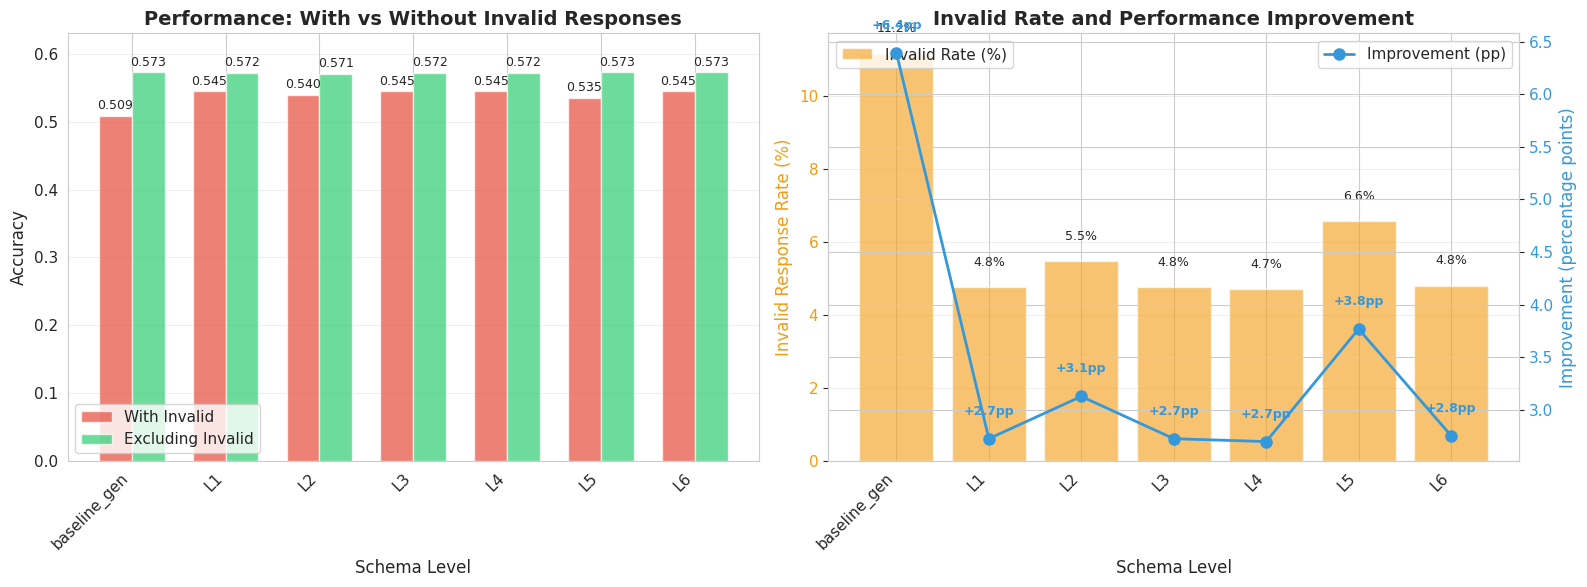

In [35]:
# Visualize performance with and without invalid responses
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Score comparison
ax1 = axes[0]
levels = comparison_df['Level'].values
x_pos = np.arange(len(levels))
width = 0.35

scores_with = comparison_df['Score (with invalid)'].values
scores_without = comparison_df['Score (no invalid)'].values

bars1 = ax1.bar(x_pos - width/2, scores_with, width, label='With Invalid', 
                alpha=0.7, color='#e74c3c')
bars2 = ax1.bar(x_pos + width/2, scores_without, width, label='Excluding Invalid', 
                alpha=0.7, color='#2ecc71')

ax1.set_xlabel('Schema Level', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Performance: With vs Without Invalid Responses', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(levels, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, max(np.nanmax(scores_with), np.nanmax(scores_without)) * 1.1])

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height) and height > 0:
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontsize=9)

# Plot 2: Invalid rate and improvement
ax2 = axes[1]
invalid_rates = comparison_df['Invalid %'].values
improvements = (comparison_df['Score (no invalid)'] - comparison_df['Score (with invalid)']).values * 100

bars3 = ax2.bar(x_pos, invalid_rates, alpha=0.6, color='#f39c12', label='Invalid Rate (%)')
ax2_twin = ax2.twinx()
line = ax2_twin.plot(x_pos, improvements, 'o-', color='#3498db', linewidth=2, 
                     markersize=8, label='Improvement (pp)')

ax2.set_xlabel('Schema Level', fontsize=12)
ax2.set_ylabel('Invalid Response Rate (%)', fontsize=12, color='#f39c12')
ax2_twin.set_ylabel('Improvement (percentage points)', fontsize=12, color='#3498db')
ax2.set_title('Invalid Rate and Performance Improvement', fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(levels, rotation=45, ha='right')
ax2.tick_params(axis='y', labelcolor='#f39c12')
ax2_twin.tick_params(axis='y', labelcolor='#3498db')
ax2.grid(axis='y', alpha=0.3)

# Add legends
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')

# Add value labels
for i, (bar, rate, imp) in enumerate(zip(bars3, invalid_rates, improvements)):
    if not np.isnan(rate):
        ax2.text(bar.get_x() + bar.get_width()/2., rate + 0.5,
                f'{rate:.1f}%',
                ha='center', va='bottom', fontsize=9)
    if not np.isnan(imp):
        ax2_twin.text(x_pos[i], imp + 0.2,
                     f'{imp:+.1f}pp',
                     ha='center', va='bottom', fontsize=9, color='#3498db', fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'performance_without_invalid.png', dpi=150, bbox_inches='tight')
plt.show()


In [36]:
# Compare schema levels against baseline_gen (excluding invalids)
print("Schema Performance vs Baseline (generate_until) - Excluding Invalid Responses:")
print("=" * 80)
print()

if 'baseline_gen' in performance_no_invalid:
    baseline_score = performance_no_invalid['baseline_gen']['score']
    baseline_invalid = performance_no_invalid['baseline_gen']['invalid_pct']
    
    print(f"Baseline (generate_until): {baseline_score:.4f} (Invalid: {baseline_invalid:.2f}%)")
    print("-" * 80)
    
    schema_levels = ['L1', 'L2', 'L3', 'L4', 'L5', 'L6']
    schema_comparison = []
    
    for level in schema_levels:
        if level in performance_no_invalid:
            score = performance_no_invalid[level]['score']
            invalid = performance_no_invalid[level]['invalid_pct']
            diff = score - baseline_score
            pct_diff = (diff / baseline_score) * 100 if baseline_score > 0 else 0
            
            schema_comparison.append({
                'Level': level,
                'Score': score,
                'Invalid %': invalid,
                'Diff vs Baseline': diff,
                'Pct Diff': pct_diff
            })
            
            status = "✓ IMPROVEMENT" if diff > 0 else "⚠️ DEGRADATION" if diff < 0 else "="
            print(f"  {level:12s}: {score:.4f} | Invalid: {invalid:5.2f}% | {status:15s} ({pct_diff:+.2f}%)")
    
    print()
    print("Summary:")
    if schema_comparison:
        print(f"  Best performing level: {max(schema_comparison, key=lambda x: x['Score'])['Level']}")
        print(f"  Average improvement: {np.mean([x['Diff vs Baseline'] for x in schema_comparison]):+.4f}")
        print(f"  Average invalid rate (schemas): {np.mean([x['Invalid %'] for x in schema_comparison]):.2f}%")
        print(f"  Baseline invalid rate: {baseline_invalid:.2f}%")
        print(f"  Invalid reduction: {baseline_invalid - np.mean([x['Invalid %'] for x in schema_comparison]):.2f} percentage points")


Schema Performance vs Baseline (generate_until) - Excluding Invalid Responses:

Baseline (generate_until): 0.5729 (Invalid: 11.16%)
--------------------------------------------------------------------------------
  L1          : 0.5723 | Invalid:  4.76% | ⚠️ DEGRADATION  (-0.11%)
  L2          : 0.5708 | Invalid:  5.47% | ⚠️ DEGRADATION  (-0.37%)
  L3          : 0.5723 | Invalid:  4.76% | ⚠️ DEGRADATION  (-0.11%)
  L4          : 0.5723 | Invalid:  4.71% | ⚠️ DEGRADATION  (-0.12%)
  L5          : 0.5729 | Invalid:  6.57% | ⚠️ DEGRADATION  (-0.00%)
  L6          : 0.5726 | Invalid:  4.81% | ⚠️ DEGRADATION  (-0.06%)

Summary:
  Best performing level: L5
  Average improvement: -0.0007
  Average invalid rate (schemas): 5.18%
  Baseline invalid rate: 11.16%
  Invalid reduction: 5.98 percentage points


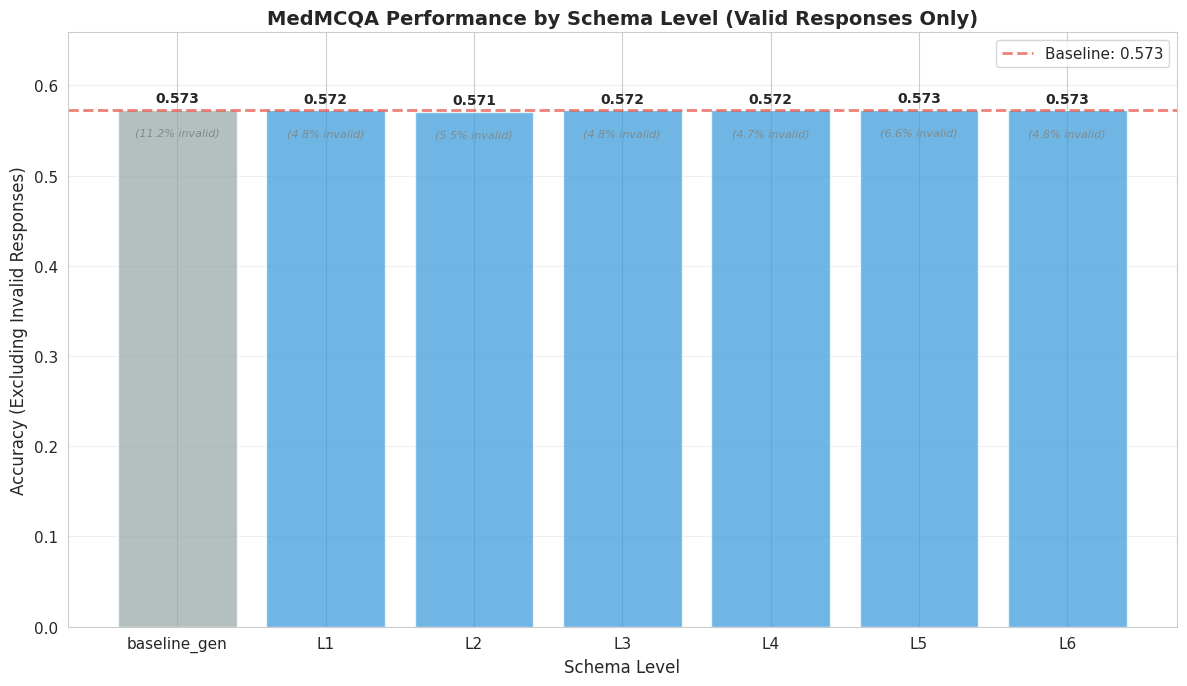

In [37]:
# Create final comparison visualization
fig, ax = plt.subplots(figsize=(12, 7))

levels_order = ['baseline_gen', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']
scores_no_invalid = [performance_no_invalid[level]['score'] if level in performance_no_invalid else np.nan 
                     for level in levels_order]
invalid_rates = [performance_no_invalid[level]['invalid_pct'] if level in performance_no_invalid else np.nan 
                 for level in levels_order]

x_pos = np.arange(len(levels_order))
bars = ax.bar(x_pos, scores_no_invalid, alpha=0.7, 
              color=['#95a5a6' if l == 'baseline_gen' else '#3498db' for l in levels_order])

# Add invalid rate as text above bars
for i, (bar, rate) in enumerate(zip(bars, invalid_rates)):
    height = bar.get_height()
    if not np.isnan(height):
        # Score label
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
        # Invalid rate label
        ax.text(bar.get_x() + bar.get_width()/2., height - 0.02,
                f'({rate:.1f}% invalid)',
                ha='center', va='top', fontsize=8, style='italic', color='#7f8c8d')

ax.set_xlabel('Schema Level', fontsize=12)
ax.set_ylabel('Accuracy (Excluding Invalid Responses)', fontsize=12)
ax.set_title('MedMCQA Performance by Schema Level (Valid Responses Only)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(levels_order)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, max([s for s in scores_no_invalid if not np.isnan(s)]) * 1.15])

# Add horizontal line for baseline
if 'baseline_gen' in performance_no_invalid:
    baseline_score = performance_no_invalid['baseline_gen']['score']
    ax.axhline(y=baseline_score, color='#e74c3c', linestyle='--', linewidth=2, 
               label=f'Baseline: {baseline_score:.3f}', alpha=0.7)
    ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'performance_no_invalid_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
